<a href="https://colab.research.google.com/github/engcriscunha/Machine-Learning---Bootcamp-Avanti/blob/main/desafio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **DESAFIO – MACHINE LEARNING – AVANTI ATLÂNTICO**

DESAFIO PROPOSTO PELO DOCENTE RENE CALIXTO:

“A seguir, apresento algumas imagens contendo problemas de Visão Computacional que podem ser discutidos nas próximas aulas síncronas. O objetivo é analisar cada cenário e propor possíveis soluções, descrevendo as etapas necessárias para desenvolver um sistema capaz de resolver o problema. É provável que, em processos seletivos para vagas na área de Visão Computacional, seja solicitado que você analise um problema semelhante e explique como o resolveria, incluindo aspectos como: Definição do objetivo do sistema; Coleta e preparação dos dados (dataset); Estratégias de anotação dos dados; Pré-processamento das imagens; Escolha do modelo ou abordagem de IA; Processo de treinamento e validação; Métricas de avaliação; Durante as discussões, o foco não será apenas identificar qual técnica utilizar, mas também justificar as decisões tomadas em cada etapa do desenvolvimento da solução.”


1)	Imagem 01 – objetivo: Contagem de objetos



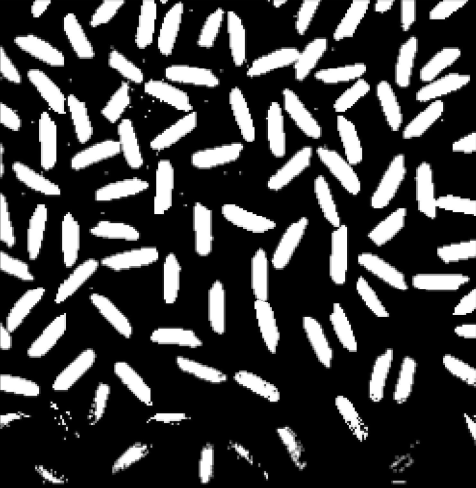


Para essa imagem, a técnica de Processamento Digital de Imagens (PDI) é a mais adequada, pois o cenário apresenta fundo uniforme, alto contraste e objetos com formato semelhante. Nessas condições, operações clássicas como filtro gaussiano, limiarização, operações morfológicas e detecção de contornos são suficientes para obter uma contagem precisa, dispensando o treinamento de modelos de Deep Learning. Caso as imagens apresentassem fundos complexos, variações de iluminação ou objetos de diferentes classes, uma abordagem baseada em CNNs (como YOLO ou Mask R-CNN) seria mais apropriada.

#### Pipeline do Sistema de Contagem de Objetos

```text
                Imagem Original
                       │
                       ▼
             Leitura da Imagem
               (OpenCV - cv2.imread)
                       │
                       ▼
        Conversão para Escala de Cinza
          (cv2.cvtColor - COLOR_BGR2GRAY)
                       │
                       ▼
         Remoção de Ruídos (Filtro Gaussiano)
            (cv2.GaussianBlur)
                       │
                       ▼
               Binarização da Imagem
              (cv2.threshold)
                       │
                       ▼
           Operações Morfológicas
      (Abertura e Fechamento - MorphologyEx)
                       │
                       ▼
      Separação de Objetos Sobrepostos
   (Distance Transform + Watershed - opcional)
                       │
                       ▼
         Detecção dos Objetos
 (findContours ou Connected Components)
                       │
                       ▼
          Contagem dos Objetos
                       │
                       ▼
      Exibição da Quantidade Encontrada
         e Visualização dos Contornos
```

In [1]:
# Importação das bibliotecas

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Importação da imagem que será avaliada

from google.colab import files

uploaded = files.upload()

Saving objetos.png to objetos.png


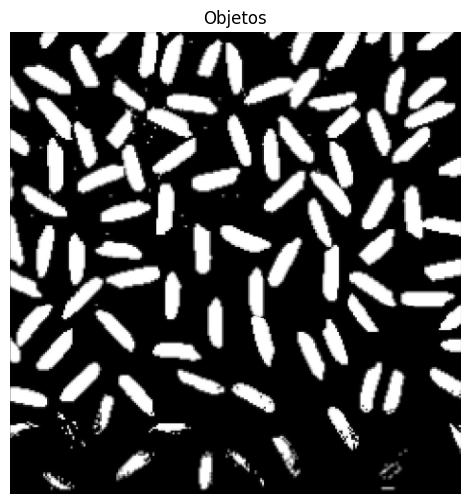

In [7]:
# Leitura da imagem
# O OpenCV utiliza o padrão BGR, por isso a conversão para RGB é necessária apenas para exibição correta no Matplotlib.

imagem = cv2.imread("objetos.png")

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB))
plt.title("Objetos")
plt.axis("off")
plt.show()

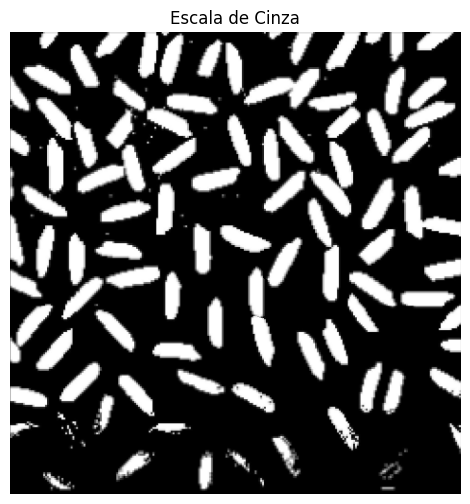

In [8]:
# Conversão da imagem para escala de cinza

cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(cinza, cmap="gray")
plt.title("Escala de Cinza")
plt.axis("off")
plt.show()

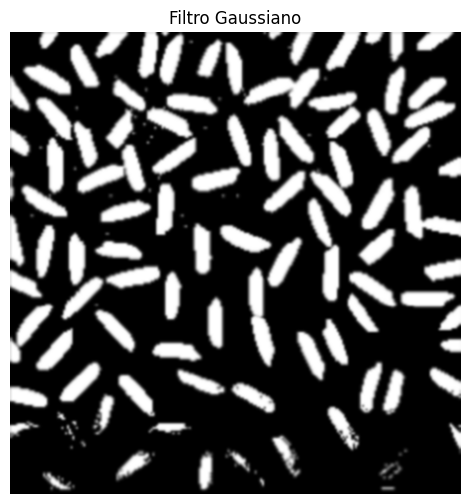

In [9]:
# Remoção de ruídos com Filtro Gaussiano

gauss = cv2.GaussianBlur(cinza, (5,5), 0)
# (5,5) é o tamanho da máscara, 0 indica que o OpenCV calculará automaticamente o valor de sigma.

plt.figure(figsize=(6,6))
plt.imshow(gauss, cmap="gray")
plt.title("Filtro Gaussiano")
plt.axis("off")
plt.show()

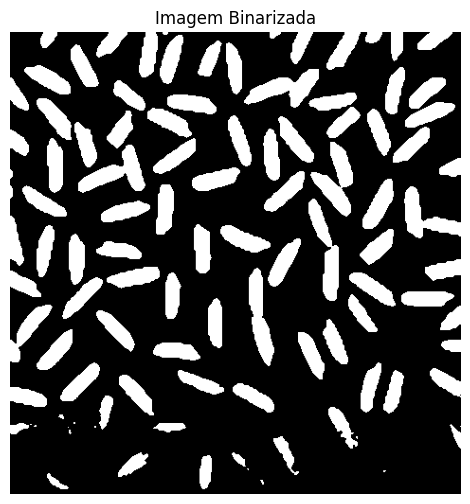

In [10]:
# Binarização (Threshold)
# Após essa etapa:
# pixels acima de 127 tornam-se 255 (brancos) e pixels abaixo tornam-se 0 (pretos). Agora existe uma separação clara entre objeto e fundo.

_, binaria = cv2.threshold(
    gauss,
    127,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(6,6))
plt.imshow(binaria, cmap="gray")
plt.title("Imagem Binarizada")
plt.axis("off")
plt.show()

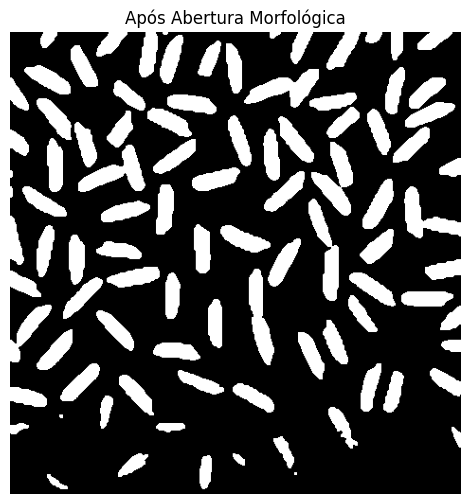

In [13]:
# Remoção de pequenos ruídos (Abertura Morfológica)

# A operação de abertura consiste em: erosão, seguida de dilatação.
# O que acontece na erosão?
# A erosão diminui os objetos brancos.Ela remove pequenos pontos e pequenas saliências.
# Depois da erosão, ocorre a dilatação.
# Ela aumenta novamente o tamanho do objeto.
# Assim, o objeto principal volta aproximadamente ao tamanho original, mas os pequenos ruídos que desapareceram na erosão não retornam.

kernel = np.ones((3,3), np.uint8)
# np.ones() → cria uma matriz preenchida com o valor 1;
# (3,3) → a matriz terá 3 linhas e 3 colunas;
# np.uint8 → cada elemento será um inteiro sem sinal de 8 bits (valores entre 0 e 255), que é o formato normalmente utilizado para imagens.

abertura = cv2.morphologyEx(
    binaria,
    cv2.MORPH_OPEN,
    kernel
)
# cv2.morphologyEx()
# Essa função aplica operações morfológicas em imagens binárias ou em escala de cinza.
# Sua sintaxe é: cv2.morphologyEx(imagem, operacao, kernel)
# Quanto maior o kernel:maior remoção de ruídos; maior o risco de alterar o formato dos objetos.

plt.figure(figsize=(6,6))
plt.imshow(abertura, cmap="gray")
plt.title("Após Abertura Morfológica")
plt.axis("off")
plt.show()



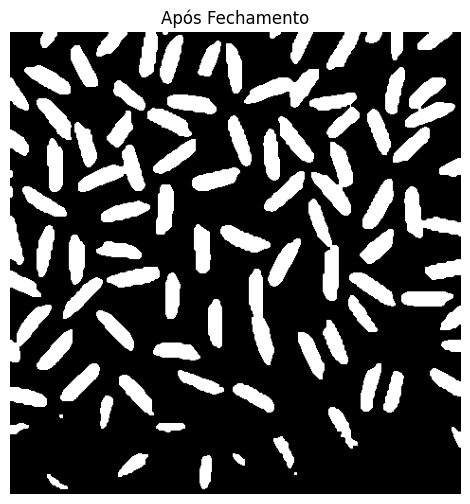

In [14]:
# Fechamento Morfológico
# O fechamento morfológico elimina pequenos buracos existentes dentro dos objetos.

fechamento = cv2.morphologyEx(
    abertura,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(6,6))
plt.imshow(fechamento, cmap="gray")
plt.title("Após Fechamento")
plt.axis("off")
plt.show()

In [15]:
# Encontrar contornos
# A função findContours() procura os contornos (bordas externas) dos objetos presentes em uma imagem binária.

contornos, _ = cv2.findContours(
    fechamento,
    cv2.RETR_EXTERNAL, # Recupera apenas os contornos externos.
    cv2.CHAIN_APPROX_SIMPLE # Armazena apenas os pontos necessários para representar o contorno. Em vez de guardar todos os pixels da borda, ele guarda apenas os vértices principais.
)